In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [114]:
df = pd.read_csv('loan_data_set.csv')

In [18]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [19]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [20]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [21]:
print('Checking For Inconsitancee data')
for i in df.select_dtypes(include=['str','category']):
    print(i,'----->',df[i].unique(),'\n')

Checking For Inconsitancee data
Loan_ID -----> <StringArray>
['LP001002', 'LP001003', 'LP001005', 'LP001006', 'LP001008', 'LP001011',
 'LP001013', 'LP001014', 'LP001018', 'LP001020',
 ...
 'LP002959', 'LP002960', 'LP002961', 'LP002964', 'LP002974', 'LP002978',
 'LP002979', 'LP002983', 'LP002984', 'LP002990']
Length: 614, dtype: str 

Gender -----> <StringArray>
['Male', 'Female', nan]
Length: 3, dtype: str 

Married -----> <StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str 

Dependents -----> <StringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str 

Education -----> <StringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str 

Self_Employed -----> <StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str 

Property_Area -----> <StringArray>
['Urban', 'Rural', 'Semiurban']
Length: 3, dtype: str 

Loan_Status -----> <StringArray>
['Y', 'N']
Length: 2, dtype: str 



In [22]:
# inconsitant data 
df['Gender'] = df['Gender'].replace({'Male':'M','Female':'F','male':'M'})

In [23]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,M,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,M,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,M,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,M,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,M,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [24]:
df.isnull().sum()*100 / len(df)

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [25]:
df.drop(columns='Loan_Status', inplace=True)

In [31]:
df.shape

(614, 13)

In [27]:
df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
dtype: object

In [33]:
#df.dropna(inplace=True)

In [36]:
df.shape

(614, 13)

In [37]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [40]:
df['Gender'] = df['Gender'].ffill(inplace=True)

/tmp/ipykernel_35031/689954082.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Gender'] = df['Gender'].ffill(inplace=True)


In [41]:
df.isnull().sum()

Loan_ID               0
Gender                0
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [42]:
#df.fillna(10)

In [43]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [44]:
df.isnull().sum()

Loan_ID               0
Gender                0
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [45]:
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])

In [46]:
df.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [48]:
df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

In [49]:
for i in df.select_dtypes(include='str'):
    df[i] = df[i].fillna(df[i].mode()[0])

In [52]:
df.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [51]:
df['LoanAmount']= df['LoanAmount'].fillna(df['LoanAmount'].mean())

In [53]:
for i in df.select_dtypes(include='float'):
    df[i] = df[i].fillna(df[i].mode())

<Axes: ylabel='LoanAmount'>

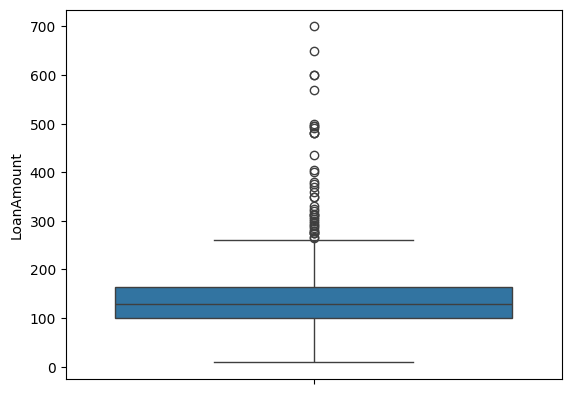

In [55]:
sns.boxplot(y=df['LoanAmount'])

<Axes: xlabel='LoanAmount', ylabel='Count'>

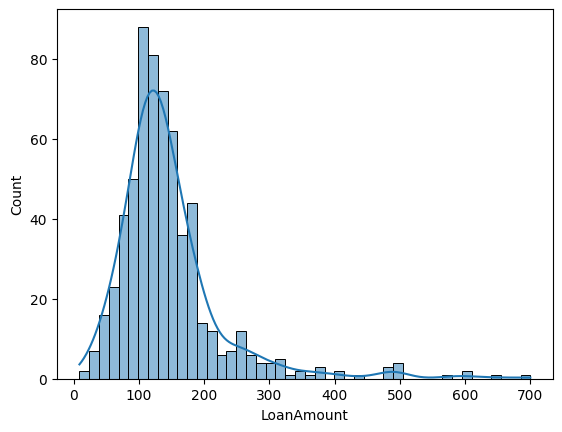

In [57]:
sns.histplot(x=df['LoanAmount'],kde=True)

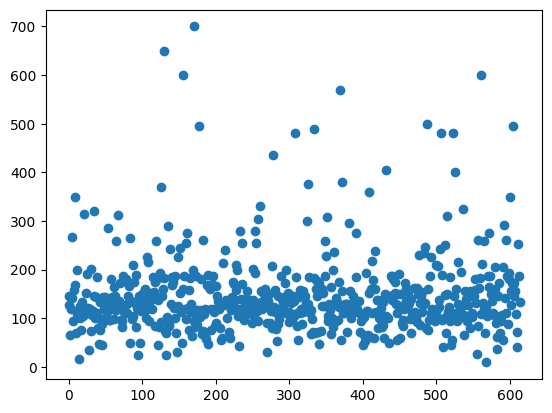

In [63]:
plt.scatter(df.index,df['LoanAmount'])

In [64]:
df.shape

(614, 13)

In [68]:
## iqr for outliers 
Q1 = df['LoanAmount'].quantile(0.25)
Q3 = df['LoanAmount'].quantile(0.75)
IQR = Q3-Q1
l_range = Q1-(1.5 * IQR)
h_range = Q3 + (1.5 * IQR)
outliers = df[(df['LoanAmount'] < l_range)| (df['LoanAmount'] > h_range)]
print(outliers.head())

df = df[(df['LoanAmount'] >= l_range) & (df['LoanAmount'] <= h_range)]

      Loan_ID  Gender Married Dependents Education Self_Employed  \
14   LP001030    Male     Yes          2  Graduate            No   
65   LP001225    Male     Yes          0  Graduate            No   
119  LP001422  Female      No          0  Graduate            No   
138  LP001492    Male      No          0  Graduate            No   
152  LP001531    Male      No          0  Graduate            No   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
14              1299             1086.0        17.0             120.0   
65              5726             4595.0       258.0             360.0   
119            10408                0.0       259.0             360.0   
138            14999                0.0       242.0             360.0   
152             9166                0.0       244.0             360.0   

     Credit_History Property_Area Loan_Status  
14              1.0         Urban           Y  
65              1.0     Semiurban           N  
119     

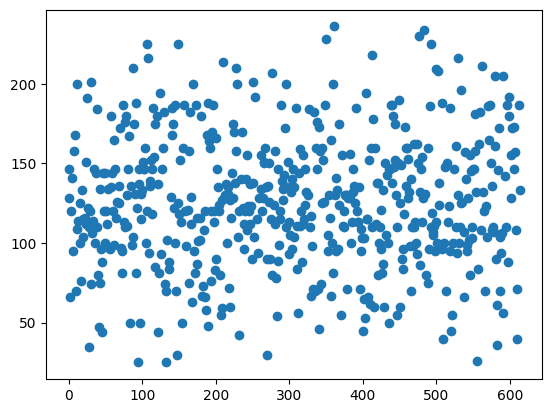

In [82]:
plt.scatter(df.index,df['LoanAmount'])

In [69]:
df.shape

(553, 13)

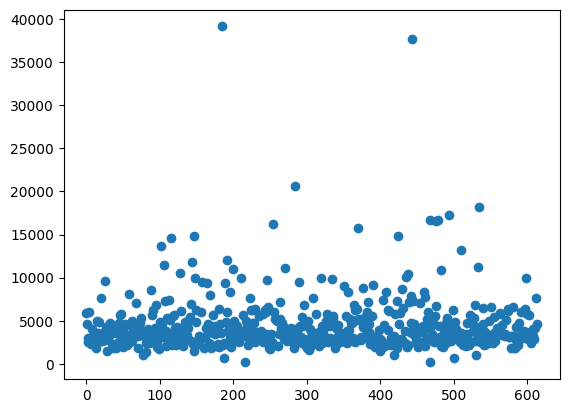

In [84]:
plt.scatter(df.index,df['ApplicantIncome'])

In [96]:
## z score for outlier 
from scipy import stats

z_score = np.abs(stats.zscore(df['ApplicantIncome']))
outliers = np.where(z_score > 2)
print(outliers)

(array([ 21,  79,  93,  97, 106, 117, 130, 133, 140, 145, 166, 168, 176,
       187, 220, 240, 256, 285, 297, 312, 334, 347, 383, 387, 390, 431,
       452, 472, 528]),)


In [97]:
df = df[z_score < 2]

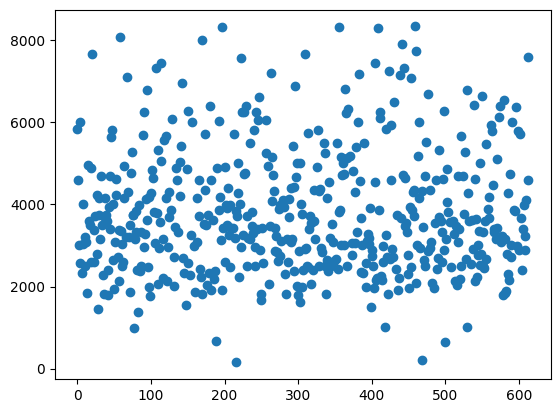

In [98]:
plt.scatter(df.index,df['ApplicantIncome'])

<Axes: xlabel='ApplicantIncome', ylabel='Count'>

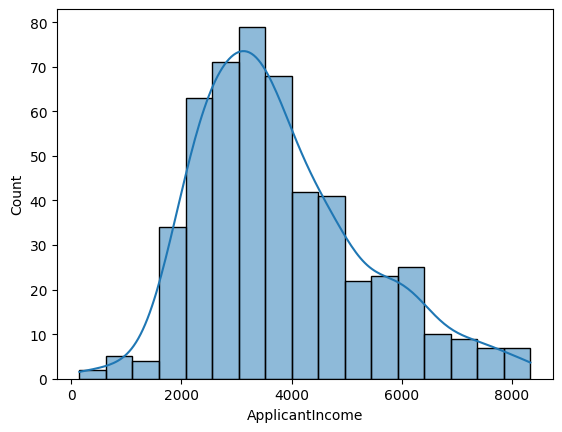

In [100]:
sns.histplot(df['ApplicantIncome'] , kde = True)


In [103]:
df['ApplicantIncome'] = np.sqrt(df['ApplicantIncome'])

<Axes: xlabel='ApplicantIncome', ylabel='Count'>

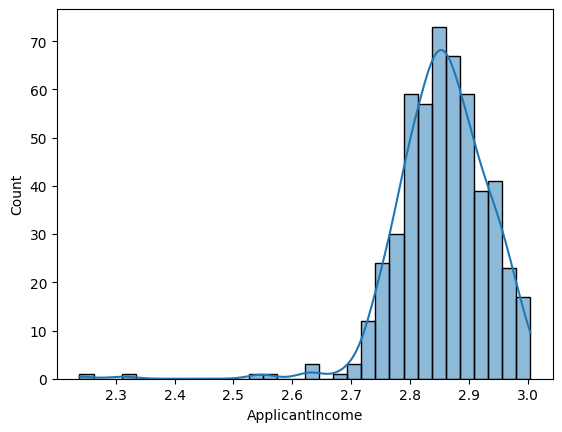

In [104]:
sns.histplot(df['ApplicantIncome'] , kde = True)


<Axes: xlabel='Loan_Amount_Term', ylabel='Count'>

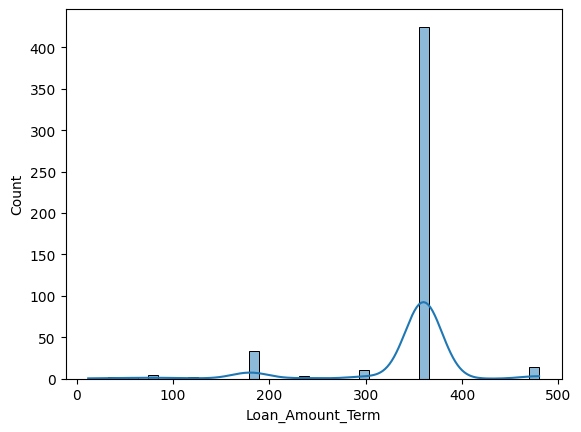

In [106]:
sns.histplot(df['Loan_Amount_Term'] , kde = True)

In [113]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,2.945170,0.0,0.594242,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,2.903465,1508.0,0.124092,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,2.829553,0.0,-1.459065,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2.802982,2358.0,-0.080187,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,2.949494,0.0,0.456044,360.0,1.0,Urban,Y


In [117]:
df['Loan_Amount_Term'] = np.log(df['Loan_Amount_Term'])

<Axes: xlabel='Loan_Amount_Term', ylabel='Count'>

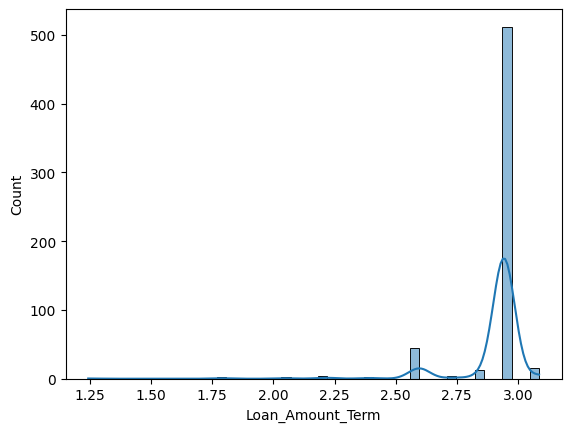

In [118]:
sns.histplot(df['Loan_Amount_Term'] , kde = True)